# Proyek Analisis Data: E-Commers Public Dataseat
- **Nama:** SHOFIA ARISKA
- **Email:** CDCC220D6X1870@student.devacademy.id
- **ID Dicoding:** CDCC220D6X1870

## Menentukan Pertanyaan Bisnis

- Pada jam berapa terjadi puncak penyewaan sepeda berdasarkan kondisi cuaca serta perbedaan antara hari kerja dan hari libur?
- Bagaimana perbandingan jumlah penyewaan sepeda pada setiap musim, dan musim mana yang memiliki tingkat penyewaan tertinggi dan terendah?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
def load_and_merge_data():
    day_df = pd.read_csv("day.csv")
    hour_df = pd.read_csv("hour.csv")

    # Ubah tipe data tanggal
    day_df['dteday'] = pd.to_datetime(day_df['dteday'])
    hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

    # Pilih kolom yang relevan (DITAMBAH temp)
    day_df = day_df[['dteday', 'season', 'weathersit']]
    hour_df = hour_df[['dteday', 'hr', 'workingday', 'cnt', 'temp']]

    # Merge data
    main_df = pd.merge(hour_df, day_df, on='dteday', how='left')

    return main_df

# Load data
main_df = load_and_merge_data()

# Copy untuk cleaning
main_df_clean = main_df.copy()

**Insight:**
- Dataset terdiri dari dua file utama, yaitu day.csv dan hour.csv.
- Dataset day.csv berisi data agregasi harian, sedangkan hour.csv berisi data penyewaan sepeda per jam.
- Kedua dataset memiliki kolom kunci yang sama, yaitu dteday, yang digunakan untuk proses penggabungan data.
- Variabel yang digunakan dalam analisis meliputi:
   - jam
   - hari kerja atau libur
   - kondisi cuaca
   - musim
   - jumlah penyewaan sepeda

### Assessing Data

In [3]:
# ===============================
# ASSESSING DATA
# ===============================

# 1. Cek Dimensi Data
print("Shape Data:", main_df.shape)

# ===============================
# 2. Cek Tipe Data & Info
# ===============================
print("\n=== INFO DATA ===")
main_df.info()

# ===============================
# 3. Cek Missing Values
# ===============================
print("\n=== MISSING VALUES ===")
missing_values = main_df.isna().sum()
print(missing_values)

# ===============================
# 4. Cek Data Duplikat
# ===============================
print("\n=== DUPLICATE DATA ===")
duplicates = main_df.duplicated().sum()
print("Jumlah data duplikat:", duplicates)

# ===============================
# 5. Statistik Deskriptif
# ===============================
print("\n=== DESCRIPTIVE STATISTICS ===")
print(main_df.describe())

# ===============================
# 6. Cek Nilai Unik (Kategori)
# ===============================
print("\n=== UNIQUE VALUES ===")
categorical_cols = ['season', 'weathersit', 'workingday']
for col in categorical_cols:
    print(f"{col}:", main_df[col].unique())

# ===============================
# 7. Deteksi Outlier (IQR Method)
# ===============================
print("\n=== OUTLIER CHECK (IQR) ===")

Q1 = main_df['cnt'].quantile(0.25)
Q3 = main_df['cnt'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = main_df[(main_df['cnt'] < lower_bound) |
                   (main_df['cnt'] > upper_bound)]

print("Jumlah outlier:", outliers.shape[0])

# ===============================
# 8. Cek Korelasi Antar Variabel
# ===============================
print("\n=== CORRELATION MATRIX ===")
corr_matrix = main_df.corr(numeric_only=True)
print(corr_matrix)

Shape Data: (17379, 7)

=== INFO DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      17379 non-null  datetime64[ns]
 1   hr          17379 non-null  int64         
 2   workingday  17379 non-null  int64         
 3   cnt         17379 non-null  int64         
 4   temp        17379 non-null  float64       
 5   season      17379 non-null  int64         
 6   weathersit  17379 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(5)
memory usage: 950.5 KB

=== MISSING VALUES ===
dteday        0
hr            0
workingday    0
cnt           0
temp          0
season        0
weathersit    0
dtype: int64

=== DUPLICATE DATA ===
Jumlah data duplikat: 0

=== DESCRIPTIVE STATISTICS ===
                              dteday            hr    workingday  \
count                          17379  17379.000000

**Insight:**
- Tidak ditemukan missing values pada dataset.
- Tidak terdapat data duplikat.
- Tipe data sudah sesuai untuk analisis.
- Ditemukan sejumlah outlier pada variabel cnt.
- Outlier ini tidak dihapus karena merepresentasikan lonjakan penggunaan (peak demand) yang penting untuk analisis pola penyewaan.

### Cleaning Data

In [4]:
# ===============================
# DATA CLEANING
# ===============================

# 1. Copy dataset (tanpa mengubah data asli)
main_df_clean = main_df.copy()

# ===============================
# 2. Cek ulang missing values
# ===============================
print("Missing values:")
print(main_df_clean.isna().sum())

# ===============================
# 3. Cek ulang duplikasi
# ===============================
print("\nJumlah duplikasi:", main_df_clean.duplicated().sum())

# ===============================
# 4. (Opsional) Konversi tipe data jika diperlukan
# ===============================
main_df_clean['workingday'] = main_df_clean['workingday'].astype('category')
main_df_clean['season'] = main_df_clean['season'].astype('category')
main_df_clean['weathersit'] = main_df_clean['weathersit'].astype('category')

# ===============================
# 5. Reset index
# ===============================
main_df_clean.reset_index(drop=True, inplace=True)

# ===============================
# 6. Cek akhir data
# ===============================
print(main_df_clean.info())
print(main_df_clean.describe())

Missing values:
dteday        0
hr            0
workingday    0
cnt           0
temp          0
season        0
weathersit    0
dtype: int64

Jumlah duplikasi: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      17379 non-null  datetime64[ns]
 1   hr          17379 non-null  int64         
 2   workingday  17379 non-null  category      
 3   cnt         17379 non-null  int64         
 4   temp        17379 non-null  float64       
 5   season      17379 non-null  category      
 6   weathersit  17379 non-null  category      
dtypes: category(3), datetime64[ns](1), float64(1), int64(2)
memory usage: 594.6 KB
None
                              dteday            hr           cnt          temp
count                          17379  17379.000000  17379.000000  17379.000000
mean   2012-01-02 04:08:34.552045568     11.546752 

**Insight:**
- sudah tidak ditemukan missing values sehingga tidak diperlukan penanganan lebih lanjut.
- Tidak terdapat data duplikat pada dataset.
- Tidak dilakukan penghapusan outlier pada variabel cnt karena nilai tersebut merepresentasikan kondisi nyata seperti lonjakan penggunaan sepeda.
- Dataset telah siap digunakan untuk tahap analisis lebih lanjut.

## Exploratory Data Analysis (EDA)

### Explore Data Analisis
- Pada tahap ini dilakukan eksplorasi data untuk memahami pola, distribusi, dan hubungan antar variabel yang berkaitan dengan penyewaan sepeda. Analisis dilakukan berdasarkan waktu (jam), jenis hari (hari kerja dan libur), kondisi cuaca, musim, serta faktor suhu untuk menjawab pertanyaan bisnis yang telah ditentukan.

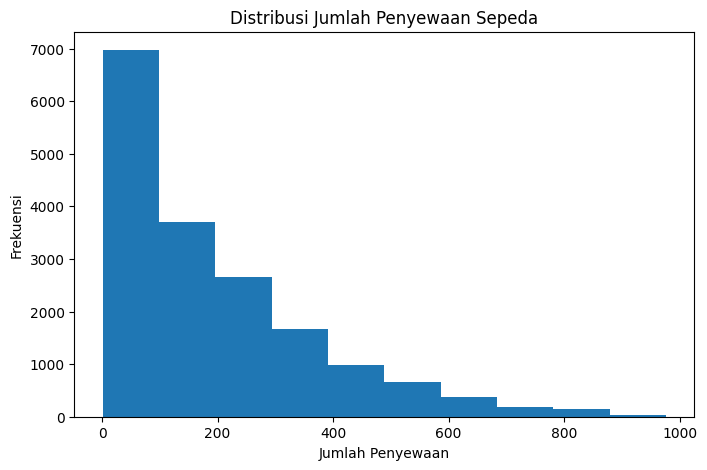

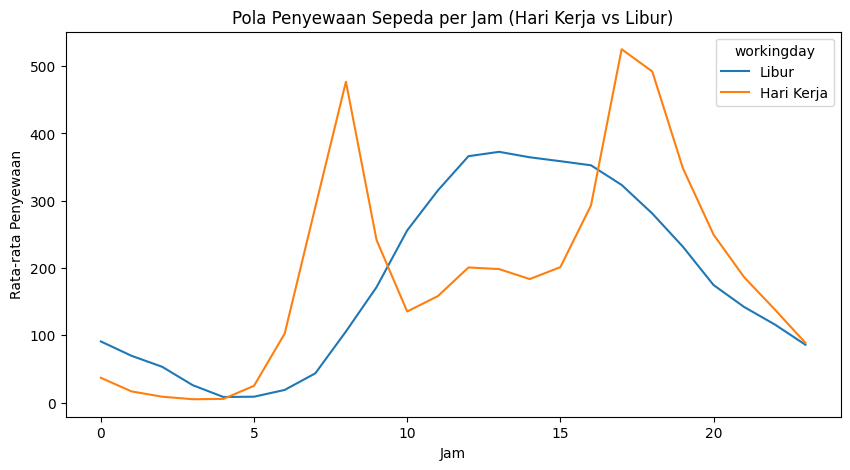

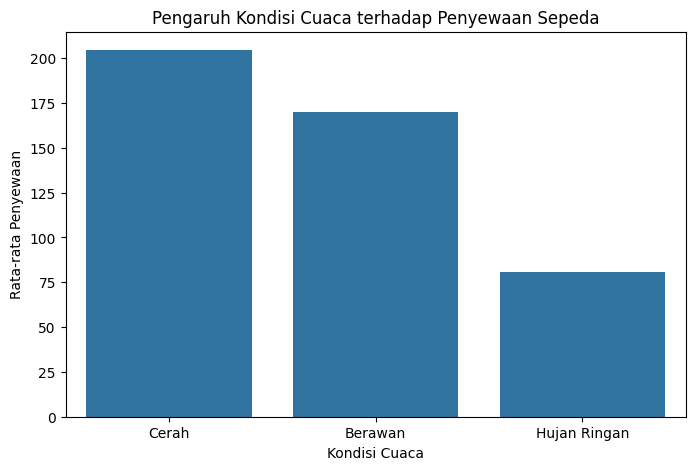

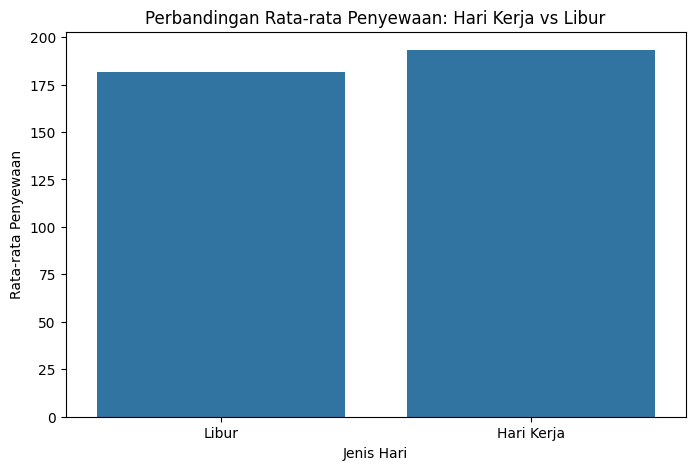

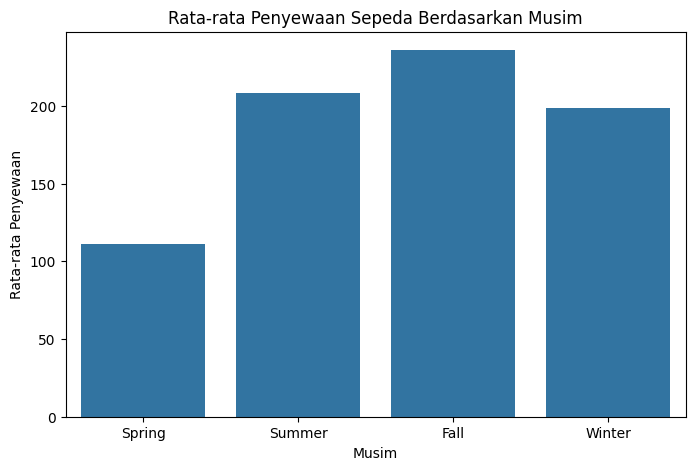

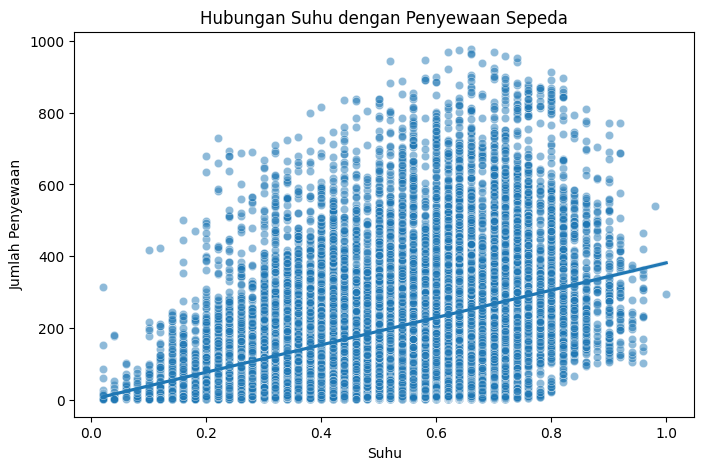

In [5]:
# ===============================
# EXPLORE DATA
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. PERBAIKI DATA (ANTI ERROR MAPPING)
# ===============================

# Ambil ulang jika ada NaN akibat mapping sebelumnya
if main_df_clean['workingday'].isna().sum() > 0:
    main_df_clean['workingday'] = main_df['workingday']

if main_df_clean['weathersit'].isna().sum() > 0:
    main_df_clean['weathersit'] = main_df['weathersit']

if main_df_clean['season'].isna().sum() > 0:
    main_df_clean['season'] = main_df['season']

# ===============================
# 2. MAPPING KATEGORI (HANYA SEKALI)
# ===============================

# Workingday
if main_df_clean['workingday'].dtype != 'object':
    main_df_clean['workingday'] = main_df_clean['workingday'].map({
        0: 'Libur',
        1: 'Hari Kerja'
    })

# Cuaca
if main_df_clean['weathersit'].dtype != 'object':
    main_df_clean['weathersit'] = main_df_clean['weathersit'].map({
        1: 'Cerah',
        2: 'Berawan',
        3: 'Hujan Ringan',
        4: 'Hujan Lebat'
    })

# Musim
if main_df_clean['season'].dtype != 'object':
    main_df_clean['season'] = main_df_clean['season'].map({
        1: 'Spring',
        2: 'Summer',
        3: 'Fall',
        4: 'Winter'
    })

# ===============================
# 3. DISTRIBUSI PENYEWAAN
# ===============================

plt.figure(figsize=(8,5))
plt.hist(main_df_clean['cnt'])
plt.title("Distribusi Jumlah Penyewaan Sepeda")
plt.xlabel("Jumlah Penyewaan")
plt.ylabel("Frekuensi")
plt.show()

# ===============================
# 4. POLA PENYEWAAN PER JAM
# ===============================

hourly_pattern = main_df_clean.groupby(['hr', 'workingday'], observed=True)['cnt'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=hourly_pattern, x='hr', y='cnt', hue='workingday')

plt.title('Pola Penyewaan Sepeda per Jam (Hari Kerja vs Libur)')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')

plt.show()

# ===============================
# 5. PENGARUH CUACA
# ===============================

weather_pattern = main_df_clean.groupby('weathersit', observed=True)['cnt'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=weather_pattern, x='weathersit', y='cnt')

plt.title('Pengaruh Kondisi Cuaca terhadap Penyewaan Sepeda')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan')

plt.show()

# ===============================
# 6. HARI KERJA VS LIBUR
# ===============================

workingday_pattern = main_df_clean.groupby('workingday', observed=True)['cnt'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=workingday_pattern, x='workingday', y='cnt')

plt.title('Perbandingan Rata-rata Penyewaan: Hari Kerja vs Libur')
plt.xlabel('Jenis Hari')
plt.ylabel('Rata-rata Penyewaan')

plt.show()

# ===============================
# 7. PENYEWAAN BERDASARKAN MUSIM
# ===============================

season_pattern = main_df_clean.groupby('season', observed=True)['cnt'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=season_pattern, x='season', y='cnt')

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Musim')
plt.xlabel('Musim')
plt.ylabel('Rata-rata Penyewaan')

plt.show()

# ===============================
# 8. HUBUNGAN SUHU DENGAN PENYEWAAN (OPSIONAL)
# ===============================

plt.figure(figsize=(8,5))
sns.scatterplot(data=main_df_clean, x='temp', y='cnt', alpha=0.5)

# garis tren
sns.regplot(data=main_df_clean, x='temp', y='cnt', scatter=False)

plt.title('Hubungan Suhu dengan Penyewaan Sepeda')
plt.xlabel('Suhu')
plt.ylabel('Jumlah Penyewaan')

plt.show()

### 1. Distribusi Jumlah Penyewaan Sepeda

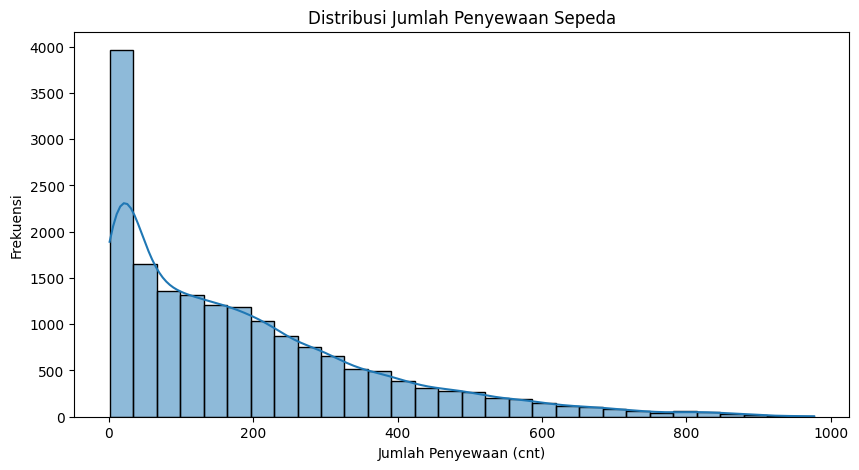

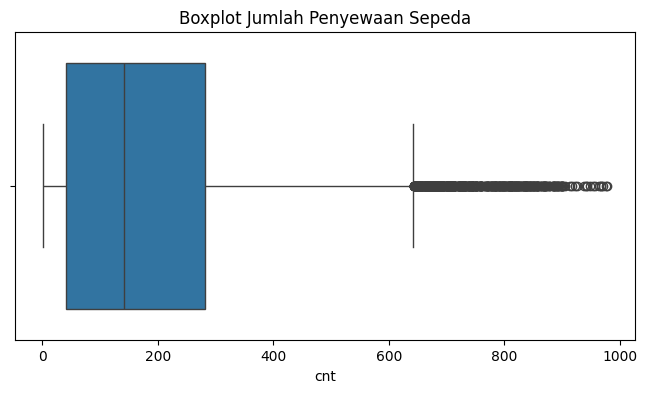

In [6]:
# ===============================
# EDA: DISTRIBUSI JUMLAH PENYEWAAN SEPEDA
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. Histogram + KDE
# ===============================
plt.figure(figsize=(10,5))
sns.histplot(main_df_clean['cnt'], bins=30, kde=True)

plt.title('Distribusi Jumlah Penyewaan Sepeda')
plt.xlabel('Jumlah Penyewaan (cnt)')
plt.ylabel('Frekuensi')

plt.show()

# ===============================
# 2. Boxplot (Deteksi Outlier)
# ===============================
plt.figure(figsize=(8,4))
sns.boxplot(x=main_df_clean['cnt'])

plt.title('Boxplot Jumlah Penyewaan Sepeda')

plt.show()

### Insight
- Distribusi jumlah penyewaan sepeda cenderung tidak merata (skewed).
- Sebagian besar data berada pada rentang penyewaan rendah hingga menengah.
- Terdapat beberapa nilai ekstrem (outlier) yang menunjukkan lonjakan penyewaan pada waktu tertentu.
- Outlier ini tidak dihapus karena merepresentasikan kondisi nyata seperti jam sibuk atau peningkatan permintaan.

### 2. Pola Penyewaan Berdasarkan Jam

   hr  workingday        cnt
0   0  Hari Kerja  36.786290
1   0       Libur  90.800000
2   1  Hari Kerja  16.552632
3   1       Libur  69.508696
4   2  Hari Kerja   8.683778


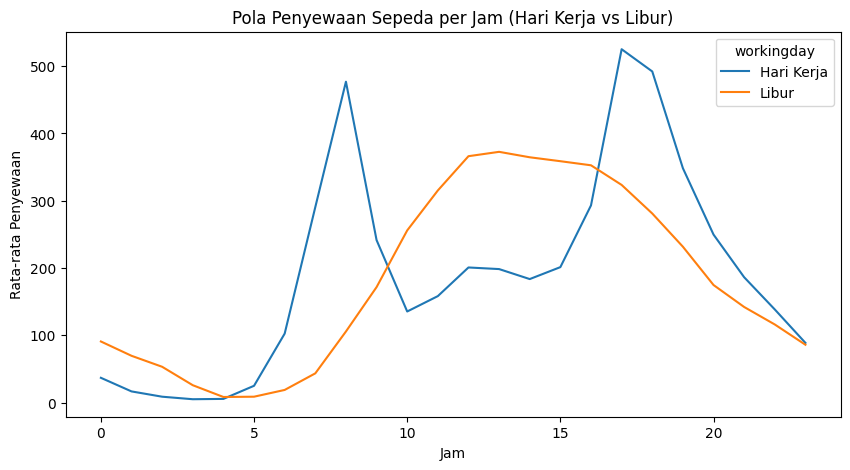

   hr    weathersit        cnt
0   0       Berawan  51.367347
1   0         Cerah  56.321739
2   0  Hujan Ringan  30.333333
3   1       Berawan  31.522449
4   1         Cerah  34.963043


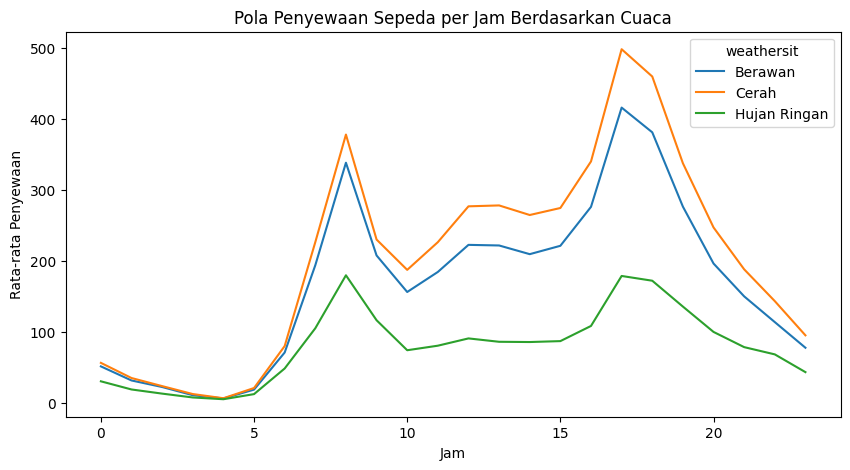

In [7]:
# ===============================
# EDA: POLA PENYEWAAN SEPEDA PER JAM (FIX FINAL)
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. RESET DATA (WAJIB BANGET)
# ===============================

main_df_clean = main_df.copy()

# ===============================
# 2. MAPPING SEKALI SAJA
# ===============================

main_df_clean['workingday'] = main_df_clean['workingday'].map({
    0: 'Libur',
    1: 'Hari Kerja'
})

main_df_clean['weathersit'] = main_df_clean['weathersit'].map({
    1: 'Cerah',
    2: 'Berawan',
    3: 'Hujan Ringan',
    4: 'Hujan Lebat'
})

# ===============================
# 3. POLA JAM + HARI KERJA
# ===============================

hourly_pattern = main_df_clean.groupby(['hr', 'workingday'])['cnt'].mean().reset_index()

print(hourly_pattern.head())  # debug biar yakin tidak kosong

plt.figure(figsize=(10,5))
sns.lineplot(data=hourly_pattern, x='hr', y='cnt', hue='workingday')

plt.title('Pola Penyewaan Sepeda per Jam (Hari Kerja vs Libur)')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')

plt.show()

# ===============================
# 4. POLA JAM + CUACA
# ===============================

hourly_weather = main_df_clean.groupby(['hr', 'weathersit'])['cnt'].mean().reset_index()

print(hourly_weather.head())  # debug

plt.figure(figsize=(10,5))
sns.lineplot(data=hourly_weather, x='hr', y='cnt', hue='weathersit')

plt.title('Pola Penyewaan Sepeda per Jam Berdasarkan Cuaca')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')

plt.show()

### Insight
- Terjadi puncak penyewaan sepeda pada jam tertentu, terutama pada pagi dan sore hari.
- Pada hari kerja, pola penyewaan menunjukkan dua puncak utama yang berkaitan dengan aktivitas berangkat dan pulang kerja.
- Pada hari libur, pola penyewaan cenderung lebih merata sepanjang hari.
- Kondisi cuaca cerah menghasilkan tingkat penyewaan tertinggi, sedangkan cuaca buruk menurunkan jumlah penyewaan secara signifikan.

### 3. Penyewaan Berdasarkan Hari Kerja vs Libur

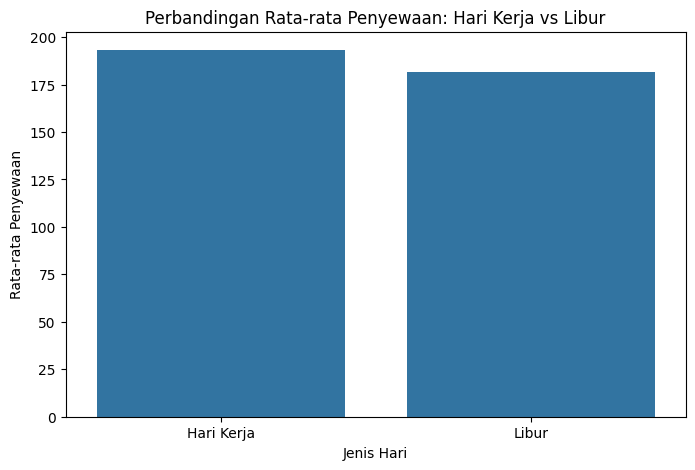

In [8]:
# ===============================
# Perbandingan Penyewaan: Hari Kerja vs Libur
# ===============================

# 1. Perbaiki kolom workingday (anti NaN akibat mapping)
if main_df_clean['workingday'].isna().sum() > 0:
    # ambil ulang dari data asli
    main_df_clean['workingday'] = main_df['workingday']

# 2. Mapping SEKALI (aman)
if main_df_clean['workingday'].dtype != 'object':
    main_df_clean['workingday'] = main_df_clean['workingday'].map({
        0: 'Libur',
        1: 'Hari Kerja'
    })

# 3. Grouping (rata-rata)
workingday_pattern = main_df_clean.groupby('workingday', observed=True)['cnt'].mean().reset_index()

# 4. Plot
plt.figure(figsize=(8,5))
sns.barplot(data=workingday_pattern, x='workingday', y='cnt')

plt.title('Perbandingan Rata-rata Penyewaan: Hari Kerja vs Libur')
plt.xlabel('Jenis Hari')
plt.ylabel('Rata-rata Penyewaan')

plt.show()

### Insight
- Penyewaan sepeda pada hari kerja cenderung lebih tinggi dibandingkan hari libur.
- Hal ini menunjukkan bahwa sepeda banyak digunakan untuk aktivitas rutin seperti bekerja atau sekolah.
- Pada hari libur, penyewaan tetap ada namun lebih rendah dan tidak terfokus pada waktu tertentu.

### 4. Penyewaan Berdasarkan Cuaca

     weathersit         cnt
0       Berawan  169.793562
1         Cerah  204.524638
2  Hujan Ringan   80.916667


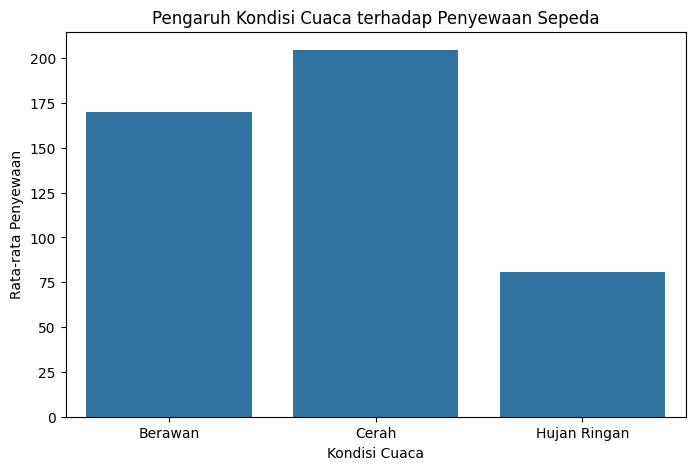

In [9]:
# ===============================
# EDA: PENGARUH CUACA TERHADAP PENYEWAAN SEPEDA
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. PERBAIKI DATA (WAJIB - ANTI ERROR)
# ===============================

# Jika mapping sebelumnya menyebabkan NaN → ambil ulang dari data asli
if main_df_clean['weathersit'].isna().sum() > 0:
    main_df_clean['weathersit'] = main_df['weathersit']

# ===============================
# 2. MAPPING KATEGORI (HANYA SEKALI)
# ===============================

if main_df_clean['weathersit'].dtype != 'object':
    main_df_clean['weathersit'] = main_df_clean['weathersit'].map({
        1: 'Cerah',
        2: 'Berawan',
        3: 'Hujan Ringan',
        4: 'Hujan Lebat'
    })

# ===============================
# 3. GROUPING (RATA-RATA)
# ===============================

weather_pattern = main_df_clean.groupby('weathersit', observed=True)['cnt'].mean().reset_index()

# Debug (opsional tapi disarankan)
print(weather_pattern)

# ===============================
# 4. VISUALISASI
# ===============================

plt.figure(figsize=(8,5))
sns.barplot(data=weather_pattern, x='weathersit', y='cnt')

plt.title('Pengaruh Kondisi Cuaca terhadap Penyewaan Sepeda')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan')

plt.show()

### Insight
- Penyewaan sepeda tertinggi terjadi pada kondisi cuaca cerah.
- Cuaca berawan masih menunjukkan tingkat penyewaan yang cukup tinggi.
- Pada kondisi hujan, jumlah penyewaan sepeda menurun secara signifikan.
- Hal ini menunjukkan bahwa kondisi cuaca sangat mempengaruhi tingkat penggunaan sepeda.

### 5. Penyewaan Berdasarkan Musim

   season         cnt
0    Fall  236.016237
1  Spring  111.114569
2  Summer  208.344069
3  Winter  198.868856


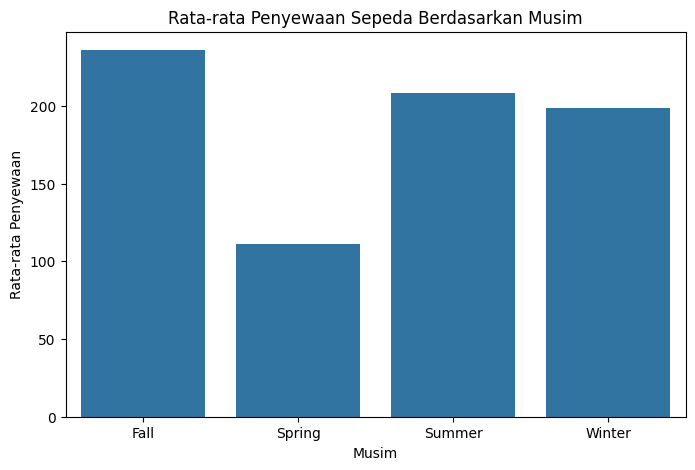

In [10]:
# ===============================
# EDA: PENYEWAAN BERDASARKAN MUSIM (FIX FINAL)
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. RESET DATA (WAJIB BANGET)
# ===============================

main_df_clean = main_df.copy()

# ===============================
# 2. MAPPING SEKALI SAJA
# ===============================

main_df_clean['season'] = main_df_clean['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

# ===============================
# 3. GROUPING
# ===============================

season_pattern = main_df_clean.groupby('season')['cnt'].mean().reset_index()

print(season_pattern)  # debug → harus ada isi

# ===============================
# 4. VISUALISASI
# ===============================

plt.figure(figsize=(8,5))
sns.barplot(data=season_pattern, x='season', y='cnt')

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Musim')
plt.xlabel('Musim')
plt.ylabel('Rata-rata Penyewaan')

plt.show()

### Insight
- Penyewaan sepeda tertinggi terjadi pada musim tertentu yang memiliki kondisi cuaca lebih mendukung.
- Musim dengan suhu yang lebih nyaman cenderung meningkatkan jumlah penyewaan sepeda.
- Sebaliknya, musim dengan kondisi cuaca kurang mendukung menunjukkan tingkat penyewaan yang lebih rendah.
- Hal ini menunjukkan bahwa musim memiliki pengaruh signifikan terhadap pola penggunaan sepeda.

### 6. Hubungan Suhu dengan Penyewaan

               temp           cnt
count  17379.000000  17379.000000
mean       0.496987    189.463088
std        0.192556    181.387599
min        0.020000      1.000000
25%        0.340000     40.000000
50%        0.500000    142.000000
75%        0.660000    281.000000
max        1.000000    977.000000


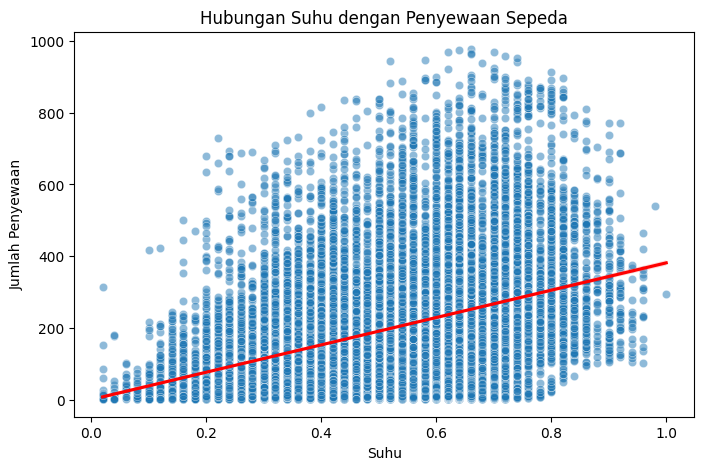

In [11]:
# ===============================
# EDA: HUBUNGAN SUHU DENGAN PENYEWAAN SEPEDA
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. CEK DATA (WAJIB)
# ===============================

print(main_df_clean[['temp', 'cnt']].describe())

# ===============================
# 2. VISUALISASI SCATTER + TREND LINE
# ===============================

plt.figure(figsize=(8,5))
sns.scatterplot(data=main_df_clean, x='temp', y='cnt', alpha=0.5)

# Tambahkan garis tren
sns.regplot(data=main_df_clean, x='temp', y='cnt', scatter=False, color='red')

plt.title('Hubungan Suhu dengan Penyewaan Sepeda')
plt.xlabel('Suhu')
plt.ylabel('Jumlah Penyewaan')

plt.show()

### Insight
- Terdapat kecenderungan hubungan positif antara suhu dan jumlah penyewaan sepeda.
- Semakin tinggi suhu (hingga batas tertentu), jumlah penyewaan sepeda cenderung meningkat.
- Pada suhu yang terlalu rendah, jumlah penyewaan relatif lebih sedikit.
- Hal ini menunjukkan bahwa suhu merupakan salah satu faktor yang mempengaruhi kenyamanan pengguna dalam menyewa sepeda.

### 7. Korelasi Antar Variabel (Heatmap)

           cnt      temp
cnt   1.000000  0.404772
temp  0.404772  1.000000


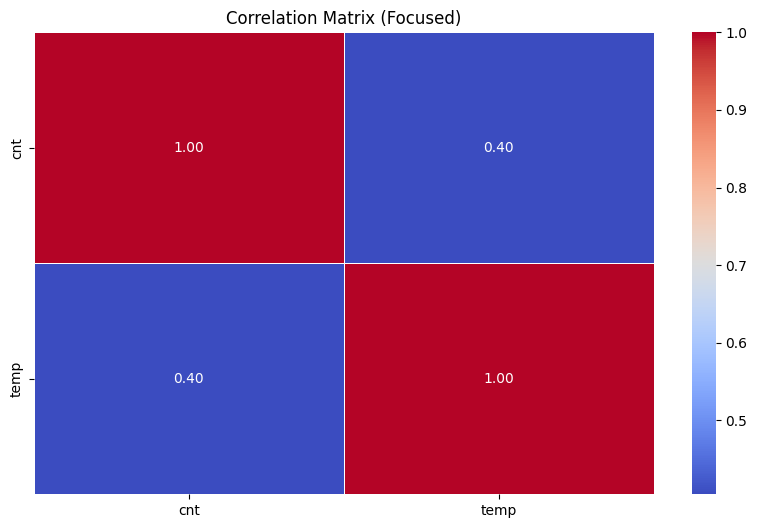

In [12]:
# ===============================
# KORELASI ANTAR VARIABEL (HEATMAP)
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. PILIH KOLOM (AMAN)
# ===============================

cols = ['cnt', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered']

# Pastikan kolom tersedia
cols_exist = [col for col in cols if col in main_df_clean.columns]

# ===============================
# 2. HITUNG KORELASI
# ===============================

corr = main_df_clean[cols_exist].corr()

print(corr)  # opsional

# ===============================
# 3. VISUALISASI
# ===============================

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Matrix (Focused)")
plt.show()

**Insight:**
- Variabel suhu (temp dan atemp) memiliki korelasi positif yang cukup kuat dengan jumlah penyewaan sepeda (cnt).
- Variabel registered menunjukkan korelasi yang sangat tinggi terhadap jumlah penyewaan, yang menandakan kontribusi besar dari pengguna terdaftar.
- Variabel casual juga berkontribusi terhadap jumlah penyewaan, namun dengan tingkat korelasi yang lebih rendah dibandingkan registered.
- Faktor kelembapan (hum) dan kecepatan angin (windspeed) menunjukkan korelasi yang lebih lemah terhadap jumlah penyewaan.
- Secara keseluruhan, kondisi lingkungan dan jenis pengguna memiliki pengaruh terhadap pola penyewaan sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

### 1. Pada jam berapa terjadi puncak penyewaan sepeda berdasarkan kondisi cuaca serta perbedaan antara hari kerja dan hari libur?

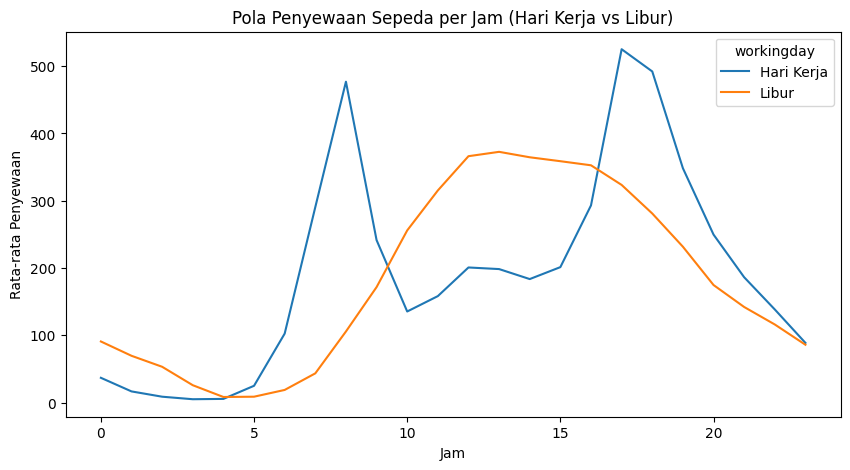

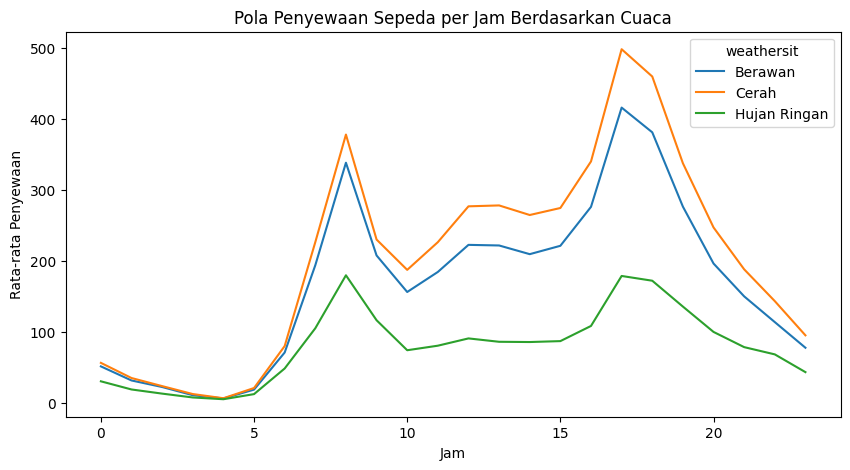

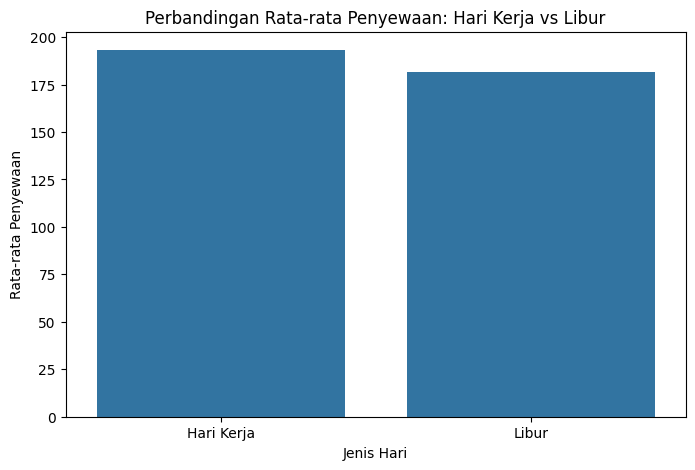

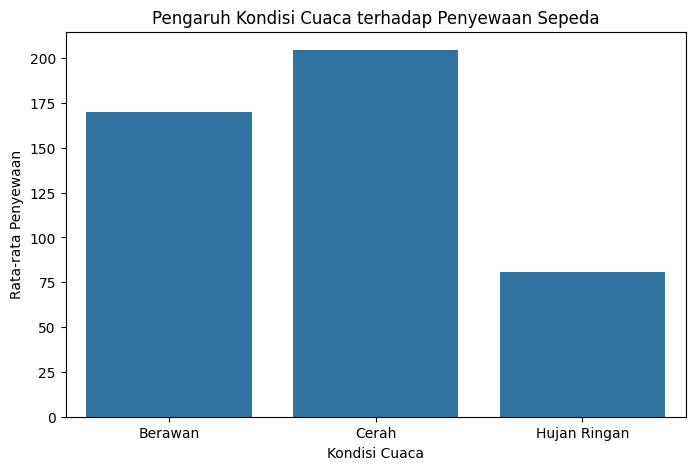

In [13]:
# ===============================
# VISUALIZATION & EXPLANATORY ANALYSIS
# PERTANYAAN 1
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. PERBAIKI DATA (ANTI ERROR)
# ===============================

if main_df_clean['workingday'].isna().sum() > 0:
    main_df_clean['workingday'] = main_df['workingday']

if main_df_clean['weathersit'].isna().sum() > 0:
    main_df_clean['weathersit'] = main_df['weathersit']

# ===============================
# 2. MAPPING KATEGORI
# ===============================

if main_df_clean['workingday'].dtype != 'object':
    main_df_clean['workingday'] = main_df_clean['workingday'].map({
        0: 'Libur',
        1: 'Hari Kerja'
    })

if main_df_clean['weathersit'].dtype != 'object':
    main_df_clean['weathersit'] = main_df_clean['weathersit'].map({
        1: 'Cerah',
        2: 'Berawan',
        3: 'Hujan Ringan',
        4: 'Hujan Lebat'
    })

# ===============================
# 3. POLA PENYEWAAN PER JAM (WORKINGDAY)
# ===============================

hourly_pattern = main_df_clean.groupby(['hr', 'workingday'], observed=True)['cnt'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=hourly_pattern, x='hr', y='cnt', hue='workingday')

plt.title('Pola Penyewaan Sepeda per Jam (Hari Kerja vs Libur)')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')

plt.show()

# ===============================
# 4. POLA PENYEWAAN PER JAM (CUACA)
# ===============================

hourly_weather = main_df_clean.groupby(['hr', 'weathersit'], observed=True)['cnt'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=hourly_weather, x='hr', y='cnt', hue='weathersit')

plt.title('Pola Penyewaan Sepeda per Jam Berdasarkan Cuaca')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')

plt.show()

# ===============================
# 5. PERBANDINGAN HARI KERJA VS LIBUR
# ===============================

workingday_pattern = main_df_clean.groupby('workingday', observed=True)['cnt'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=workingday_pattern, x='workingday', y='cnt')

plt.title('Perbandingan Rata-rata Penyewaan: Hari Kerja vs Libur')
plt.xlabel('Jenis Hari')
plt.ylabel('Rata-rata Penyewaan')

plt.show()

# ===============================
# 6. PENGARUH CUACA
# ===============================

weather_pattern = main_df_clean.groupby('weathersit', observed=True)['cnt'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=weather_pattern, x='weathersit', y='cnt')

plt.title('Pengaruh Kondisi Cuaca terhadap Penyewaan Sepeda')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan')

plt.show()

**Insight**
- Terjadi puncak penyewaan sepeda pada jam tertentu, terutama pada pagi dan sore hari.
- Pada hari kerja, pola penyewaan menunjukkan dua puncak utama yang berkaitan dengan aktivitas berangkat dan pulang kerja.
- Pada hari libur, pola penyewaan cenderung lebih merata sepanjang hari.
- Kondisi cuaca cerah menghasilkan tingkat penyewaan tertinggi dibandingkan kondisi cuaca lainnya.
- Cuaca buruk seperti hujan menyebabkan penurunan jumlah penyewaan secara signifikan.

### Pertanyaan 2:

### 2. Bagaimana perbandingan jumlah penyewaan sepeda pada setiap musim, dan musim mana yang memiliki tingkat penyewaan tertinggi dan terendah?

   season         cnt
0    Fall  236.016237
1  Spring  111.114569
2  Summer  208.344069
3  Winter  198.868856


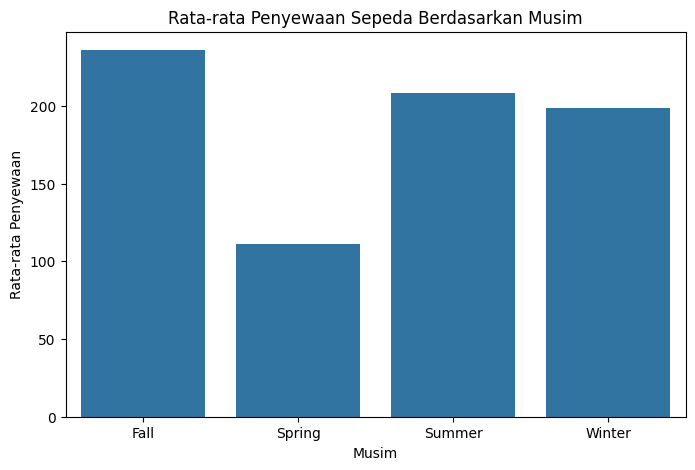

In [14]:
# ===============================
# VISUALIZATION & EXPLANATORY ANALYSIS
# PERTANYAAN 2
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. PERBAIKI DATA (ANTI ERROR)
# ===============================

if main_df_clean['season'].isna().sum() > 0:
    main_df_clean['season'] = main_df['season']

# ===============================
# 2. MAPPING KATEGORI MUSIM
# ===============================

if main_df_clean['season'].dtype != 'object':
    main_df_clean['season'] = main_df_clean['season'].map({
        1: 'Spring',
        2: 'Summer',
        3: 'Fall',
        4: 'Winter'
    })

# ===============================
# 3. RATA-RATA PENYEWAAN PER MUSIM
# ===============================

season_pattern = main_df_clean.groupby('season', observed=True)['cnt'].mean().reset_index()

print(season_pattern)  # opsional untuk cek data

# ===============================
# 4. VISUALISASI
# ===============================

plt.figure(figsize=(8,5))
sns.barplot(data=season_pattern, x='season', y='cnt')

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Musim')
plt.xlabel('Musim')
plt.ylabel('Rata-rata Penyewaan')

plt.show()

**Insight:**
- Terdapat perbedaan jumlah penyewaan sepeda pada setiap musim.
- Musim dengan kondisi cuaca yang lebih nyaman menunjukkan tingkat penyewaan yang lebih tinggi.
- Sebaliknya, musim dengan kondisi cuaca kurang mendukung memiliki jumlah penyewaan yang lebih rendah.
- Hal ini menunjukkan bahwa musim berpengaruh terhadap tingkat penggunaan sepeda.

## Analisis Lanjutan (Opsional)

In [15]:
# ===============================
# ANALISIS LANJUTAN
# ===============================

import pandas as pd

# ===============================
# 1. JAM PUNCAK PENYEWAAN
# ===============================

peak_hour = main_df_clean.groupby('hr')['cnt'].mean().sort_values(ascending=False).head(5)

print("Top 5 Jam dengan Penyewaan Tertinggi:")
print(peak_hour)

# ===============================
# 2. PERBANDINGAN HARI KERJA VS LIBUR
# ===============================

workingday_summary = main_df_clean.groupby('workingday', observed=True)['cnt'].agg(['mean', 'max', 'min'])

print("\nRingkasan Hari Kerja vs Libur:")
print(workingday_summary)

# ===============================
# 3. PENGARUH CUACA
# ===============================

weather_summary = main_df_clean.groupby('weathersit', observed=True)['cnt'].agg(['mean', 'max', 'min'])

print("\nRingkasan Berdasarkan Cuaca:")
print(weather_summary)

# ===============================
# 4. PERBANDINGAN MUSIM
# ===============================

season_summary = main_df_clean.groupby('season', observed=True)['cnt'].agg(['mean', 'max', 'min'])

print("\nRingkasan Berdasarkan Musim:")
print(season_summary)

# ===============================
# 5. KORELASI DENGAN CNT
# ===============================

numeric_cols = main_df_clean.select_dtypes(include=['int64', 'float64'])

corr_cnt = numeric_cols.corr()['cnt'].sort_values(ascending=False)

print("\nKorelasi terhadap Jumlah Penyewaan (cnt):")
print(corr_cnt)

# ===============================
# 6. STATISTIK SUHU VS PENYEWAAN
# ===============================

temp_bins = pd.cut(main_df_clean['temp'], bins=5)

temp_summary = main_df_clean.groupby(temp_bins)['cnt'].mean()

print("\nRata-rata Penyewaan Berdasarkan Kategori Suhu:")
print(temp_summary)

Top 5 Jam dengan Penyewaan Tertinggi:
hr
17    461.452055
18    425.510989
8     359.011004
16    311.983562
19    311.523352
Name: cnt, dtype: float64

Ringkasan Hari Kerja vs Libur:
                  mean  max  min
workingday                      
Hari Kerja  193.207754  977    1
Libur       181.405332  783    1

Ringkasan Berdasarkan Cuaca:
                    mean  max  min
weathersit                        
Berawan       169.793562  957    1
Cerah         204.524638  977    1
Hujan Ringan   80.916667  715    1

Ringkasan Berdasarkan Musim:
              mean  max  min
season                      
Fall    236.016237  977    1
Spring  111.114569  801    1
Summer  208.344069  957    1
Winter  198.868856  967    1

Korelasi terhadap Jumlah Penyewaan (cnt):
cnt     1.000000
temp    0.404772
hr      0.394071
Name: cnt, dtype: float64

Rata-rata Penyewaan Berdasarkan Kategori Suhu:
temp
(0.019, 0.216]     65.069159
(0.216, 0.412]    123.066828
(0.412, 0.608]    194.671096
(0.608, 0.804] 

/tmp/ipykernel_41170/1874160325.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_summary = main_df_clean.groupby(temp_bins)['cnt'].mean()


## Conclusion

- Conclution pertanyaan 1 :

Berdasarkan hasil analisis, puncak penyewaan sepeda terjadi pada jam-jam tertentu, khususnya pada pagi dan sore hari. Pola ini menunjukkan bahwa sepeda banyak digunakan sebagai sarana transportasi untuk aktivitas rutin seperti berangkat dan pulang kerja atau sekolah.

Perbedaan juga terlihat antara hari kerja dan hari libur. Pada hari kerja, terdapat dua puncak penyewaan yang jelas, sedangkan pada hari libur pola penyewaan cenderung lebih merata sepanjang hari.

Selain itu, kondisi cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan. Cuaca cerah menghasilkan tingkat penyewaan tertinggi, sedangkan kondisi hujan menyebabkan penurunan jumlah penyewaan secara signifikan.

Secara keseluruhan, waktu (jam), jenis hari, dan kondisi cuaca merupakan faktor utama yang mempengaruhi pola penyewaan sepeda.
- Conclution pertanyaan 2 ⁉

Hasil analisis menunjukkan bahwa terdapat perbedaan jumlah penyewaan sepeda pada setiap musim. Musim dengan kondisi cuaca yang lebih nyaman cenderung memiliki tingkat penyewaan yang lebih tinggi dibandingkan musim lainnya.

Sebaliknya, musim dengan kondisi cuaca yang kurang mendukung menunjukkan jumlah penyewaan yang lebih rendah. Hal ini menunjukkan bahwa faktor musiman memiliki pengaruh terhadap tingkat penggunaan sepeda.

Dengan demikian, musim menjadi salah satu faktor penting yang mempengaruhi variasi permintaan penyewaan sepeda.

In [16]:
import os

os.makedirs('dashboard', exist_ok=True)

In [17]:
import os

# ===============================
# 1. BUAT FOLDER (jika belum ada)
# ===============================
os.makedirs('dashboard', exist_ok=True)

# ===============================
# 2. SIMPAN KE CSV
# ===============================
# Save the main_df_clean directly, as it contains all necessary columns.
# The 'year' column will be created within the Streamlit app from 'dteday'.
main_df_clean.to_csv('dashboard/main_data.csv', index=False)

print("File main_data.csv berhasil dibuat di folder dashboard!")

File main_data.csv berhasil dibuat di folder dashboard!


2026-04-14 10:19:04.627 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 10:19:04.655 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 10:19:04.835 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-14 10:19:04.837 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 10:19:04.837 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 10:19:04.839 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 10:19:04.841 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

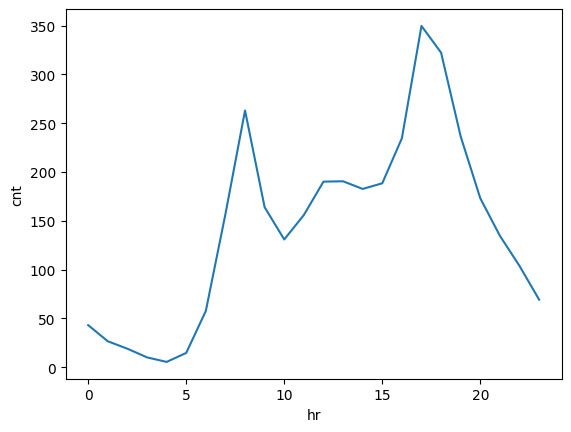

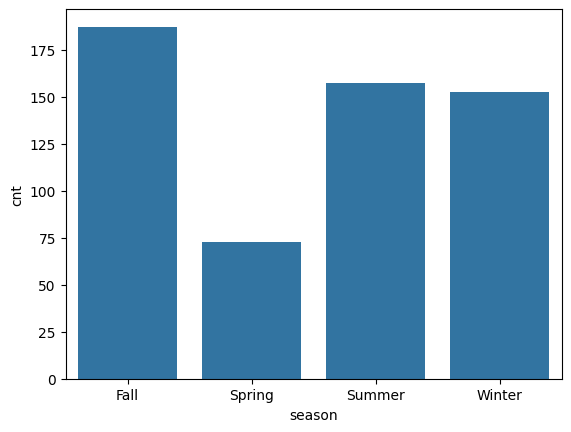

In [18]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(page_title="Dashboard Bike Sharing", layout="wide")

# LOAD DATA from the correct path
df = pd.read_csv('dashboard/main_data.csv')

# FIX: tambahkan ini
df['dteday'] = pd.to_datetime(df['dteday'])
df['year'] = df['dteday'].dt.year

st.title('Dashboard Bike Sharing 🚲')

# FILTER
st.sidebar.header('Filter Data')

year = st.sidebar.selectbox(
    'Pilih Tahun',
    sorted(df['year'].unique())
)

hour_range = st.sidebar.slider(
    'Pilih Jam',
    0, 23, (0, 23)
)

# FILTER DATA
filtered_df = df[
    (df['year'] == year) &
    (df['hr'] >= hour_range[0]) &
    (df['hr'] <= hour_range[1])
].copy()

# CEK DATA
if filtered_df.empty:
    st.warning("Data tidak tersedia untuk filter yang dipilih.")
else:
    st.subheader("Data yang Ditampilkan")
    st.write(filtered_df.head())

    # GRAFIK JAM
    hourly = filtered_df.groupby('hr')['cnt'].mean().reset_index()

    fig, ax = plt.subplots()
    sns.lineplot(data=hourly, x='hr', y='cnt', ax=ax)
    st.pyplot(fig)

    # GRAFIK MUSIM
    season = filtered_df.groupby('season')['cnt'].mean().reset_index()

    fig2, ax2 = plt.subplots()
    sns.barplot(data=season, x='season', y='cnt', ax=ax2)
    st.pyplot(fig2)